<a href="https://colab.research.google.com/github/kennethkvs/RetinalDiseasesOCTClassifier/blob/main/RetinalDiseaseOCTClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMPSCI 4AL3 Project: Retinal Disease OCT Classifier

## Folder Structure

```
RetinalDiseasesOCTClassifier
├── Dataset
│   ├── train
|   │   ├───── CNV
|   │   |       └── augmented
|   |   ├───── DME
|   │   |       └── augmented
|   │   ├───── DRUSEN
|   │   |       └── augmented
|   │   └───── NORMAL 
|   |           └── augmented
│   ├── val
|   │   ├───── CNVW
|   │   ├───── DME
|   │   ├───── DRUSEN
|   │   └───── NORMAL
│   └── test
│       ├───── CNV
│       ├───── DME
│       ├───── DRUSEN
│       └───── NORMAL
├── Group 76 Progress 2
├── Project Progress Report
|   └── Proposal Latex
|       └── Images
├── Trained_Model
├── README.md
└── RetinalDiseaseOCTClassifier.ipynb
```

In [1]:
# ---------------------- Imports ----------------------

# General Imports
import os
import numpy as np
import pandas as pd
import random
from PIL import Image

# PyTorch Imports
import torch
from torchvision.transforms import v2 as image_preprocess
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms

# Sklearn Imports
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matplotlib Imports
import matplotlib.pyplot as plt
from matplotlib import cm

# Extra Imports
import copy
from warmup_scheduler import GradualWarmupScheduler

## Preprocessing Dataset

### Resources Used

Despite not being required, we wanted to state the resources that we used to create the following dataset class definition, preprocessing, ResNet-50 neural network model implementation.

- https://docs.pytorch.org/vision/main/transforms.html
- GitHub Copilot Autocomplete was used to help construct some sections of the code, in addition to helping autocomplete some redundent code elements that were already present in the code and just needed to be written again and writing the comments seen throughout the code. Since data is not available regarding the carbon emissions of GitHub Copilot autocomplete, we will be treating each autocomplete as a ChatGPT querry as GitHub Copilot is powered by ChatGPT. Therefore, using the provided metric of 4.32g of carbon emissions for a ChatGPT querry, we will be estimating my total carbon emission for using GitHub Copilot autocomplete for comments and writing redudent code at 4.32g x 20 = 86.4g.

In [2]:
# ---------------------- Dataset Class Definition ----------------------

class OCTImageDataset:
    def __init__(self, data_dir: str, type: str):
        self.data_dir = data_dir
        self.type = type
        # Define label mapping
        self.label_mapping = {
            'CNV': 0,
            'DME': 1,
            'DRUSEN': 2,
            'NORMAL': 3
        }
        self.image_paths = []
        self.classes = list(self.label_mapping.keys())
        self.labels = []
        self.image_processor = None

        # Initialize class attributes
        match type:
            case 'train':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Different transformations
                    image_preprocess.RandomHorizontalFlip(),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case 'test' | 'val':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case _:
                raise ValueError("Type must be 'train', 'val', or 'test'.")
        self.load_data()
        
    # Load data from directory, including augmentation folders
    def load_data(self):
        for label in os.listdir(self.data_dir):
            label_dir = os.path.join(self.data_dir, label)
            if os.path.isdir(label_dir):
                # Load original images
                for image_file in os.listdir(label_dir):
                    if image_file.endswith(('.png', '.jpg', '.jpeg')):
                        image_path = os.path.join(label_dir, image_file)
                        self.image_paths.append(image_path)
                        self.labels.append(self.label_mapping[label])
                # Load images from augmentation subfolders (if any)
                for subfolder in os.listdir(label_dir):
                    subfolder_path = os.path.join(label_dir, subfolder)
                    if os.path.isdir(subfolder_path) and subfolder.lower().startswith("aug"):
                        for image_file in os.listdir(subfolder_path):
                            if image_file.endswith(('.png', '.jpg', '.jpeg')):
                                image_path = os.path.join(subfolder_path, image_file)
                                self.image_paths.append(image_path)
                                self.labels.append(self.label_mapping[label])
        print(f"Loaded {len(self.image_paths)} images for {self.type} set.")

    # Visualize dataset statistics and sample images
    def visualize(self):
        # Print out dataset statistics
        class_counts = {
            'CNV': self.labels.count(0),
            'DME': self.labels.count(1),
            'DRUSEN': self.labels.count(2),
            'NORMAL': self.labels.count(3)
        }
        print(f"Visualizing dataset statistics for {self.type} set{' (Post Augmentation)' if self.type == 'train' else ''}:")
        for class_name, count in class_counts.items():
            print(f"{class_name}: {count} images")
        
        # Plot class distribution
        plt.bar(class_counts.keys(), class_counts.values())
        plt.title(f'Class Distribution in {self.type} Set{" (Post Augmentation)" if self.type == "train" else ""}')
        plt.xlabel('Classes')
        plt.ylabel('Number of Images')
        plt.show()

        # Display sample images from each class
        plt.figure(figsize=(12, 6))
        for class_name in self.classes:
            # Pick the first image from each class for visualization
            image_path = os.path.join(self.data_dir, class_name, os.listdir(os.path.join(self.data_dir, class_name))[1])
            image = Image.open(image_path)
            plt.subplot(1, 4, self.label_mapping[class_name] + 1)
            plt.imshow(image, cmap='gray') # Image data is grayscale idk why without cmap it isn't grayscale
            plt.title(class_name)
        plt.show()

    # Needed for PyTorch DataLoader compatibility
    def __len__(self):
        if len(self.image_paths) != len(self.labels):
            raise ValueError("Mismatch between number of images and labels.")
        if len(self.image_paths) == 0 or len(self.labels) == 0:
            raise ValueError("No images found in the dataset.")

        return len(self.image_paths)
    
    # Needed for PyTorch DataLoader compatibility
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')
        if self.image_processor:
            image = self.image_processor(image)
        else:
            raise ValueError("Image processor not defined.")
        
        return image, label
    
    def counts(self):
        return self.class_counts


In [3]:
# ---------------------- Data Configurations ----------------------

batch_size = 64
shuffle_data = True

# Main dataset and all the images
# train_data_dir = 'Dataset/train'
# test_data_dir = 'Dataset/test'
# val_data_dir = 'Dataset/val'

# # Using only 5000 images for fast computation
train_data_dir = '10000_images_only/train'
test_data_dir = '10000_images_only/test'
val_data_dir = '10000_images_only/val'

## Augmentation

Since the initial skew for the training data is very high for the CNV class, we will be applying some data augmentation techniques to the training data in order to help balance the classes a bit more. The augmentated images will be store in a seperate folder within each training class called "augmented". This will allow for easier organization and seperation from the original images.

If these images already exist, then the augmentation process will be skipped to save time.

### Resources Used

- https://docs.pytorch.org/vision/main/transforms.html
- For this part, the method of augmenting the image was determined by using GitHub Copilot queries. In addition to this, two print lines were autocompleted. Just to round it to around 5 queries to be safe, we estimate the carbon emissions at 4.32g x 5 = 21.6g. The method of calculation the carbon emission is the same as the previous section.

In [4]:
categories = ["CNV", "DME", "DRUSEN", "NORMAL"]

def count_images_in_folder(folder_path):
    return len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

folders = [os.path.join("Dataset/train", cls) for cls in categories]

# Returns the number of non augmented images in each folder
image_counts = [count_images_in_folder(folder) for folder in folders]

# Finds the folder with the most images, and every other folder will be augmented to match this number
max_images = max(image_counts)
print("Folders", folders)
print("Categories", categories)
print("image_counts", image_counts)

# ----------------------------------------------------
# Define augmentation transforms
# ----------------------------------------------------
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

# ----------------------------------------------------
# Helper: save augmented version of an image
# ----------------------------------------------------
def augment_and_save(image_path, save_dir, augment_id):
    img = Image.open(image_path).convert("RGB")
    aug_img = augmentation_transforms(img)
    base, ext = os.path.splitext(os.path.basename(image_path))
    new_filename = f"{base}_{augment_id}{ext}"
    aug_img.save(os.path.join(save_dir, "augmented", new_filename))

# ----------------------------------------------------
# Main augmentation logic
# ----------------------------------------------------
def balance_class_folders(root_dir, classes):
    # Count images in each class folder
    def count_images(path):
        return len([f for f in os.listdir(path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    folder_paths = [os.path.join(root_dir, cls) for cls in classes]

    # Ensure all 'augmented' folders exist before counting
    for path in folder_paths:
        augmented_folder = os.path.join(path, "augmented")
        if not os.path.exists(augmented_folder):
            os.makedirs(augmented_folder)

    # Compute total images (original + augmented) for each class
    counts = []
    for path in folder_paths:
        orig_count = count_images(path)
        aug_count = count_images(os.path.join(path, "augmented"))
        counts.append(orig_count + aug_count)

    max_images = max(counts)
    print(f"Max class count (including augmented) = {max_images}")

    # Augment each class up to max_images
    for cls, path in zip(classes, folder_paths):
        orig_count = count_images(path)
        aug_count = count_images(os.path.join(path, "augmented"))
        total_count = orig_count + aug_count
        print(f"\nClass: {cls} — {orig_count} images + {aug_count} augmented images = {total_count}")

        if total_count == max_images:
            print("Already balanced.")
            continue

        needed = max_images - total_count
        print(f"→ Need {needed} augmented images")

        # List original images
        image_filenames = [f for f in os.listdir(path)
                           if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for i in range(needed):
            # Randomly pick an original image to augment
            src_img = random.choice(image_filenames)
            src_img_path = os.path.join(path, src_img)
            augment_and_save(src_img_path, path, augment_id=i)

        print(f"✓ Done: folder now has {max_images} images")

    print("\nAll folders balanced successfully.")


# Balance the class folders in the training dataset
balance_class_folders("Dataset/train", categories)


Folders ['Dataset/train\\CNV', 'Dataset/train\\DME', 'Dataset/train\\DRUSEN', 'Dataset/train\\NORMAL']
Categories ['CNV', 'DME', 'DRUSEN', 'NORMAL']
image_counts [37205, 11348, 8616, 26315]
Max class count (including augmented) = 37205

Class: CNV — 37205 images + 0 augmented images = 37205
Already balanced.

Class: DME — 11348 images + 25857 augmented images = 37205
Already balanced.

Class: DRUSEN — 8616 images + 28589 augmented images = 37205
Already balanced.

Class: NORMAL — 26315 images + 10890 augmented images = 37205
Already balanced.

All folders balanced successfully.


Visualizing dataset statistics for train set (Pre Augmentation):
CNV: 37205 images
DME: 11348 images
DRUSEN: 8616 images
NORMAL: 26315 images


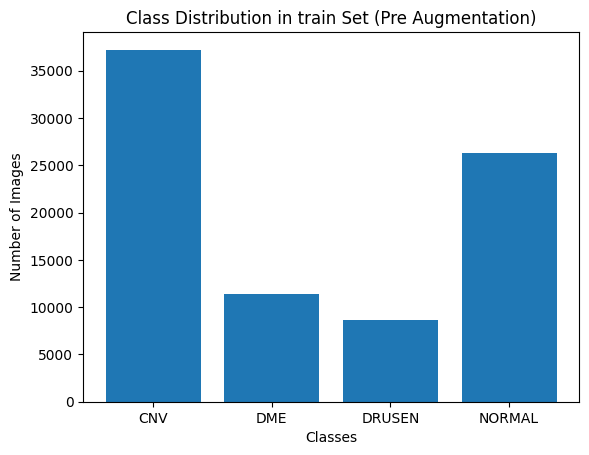

Loaded 10000 images for train set.
Visualizing dataset statistics for train set (Post Augmentation):
CNV: 2500 images
DME: 2500 images
DRUSEN: 2500 images
NORMAL: 2500 images


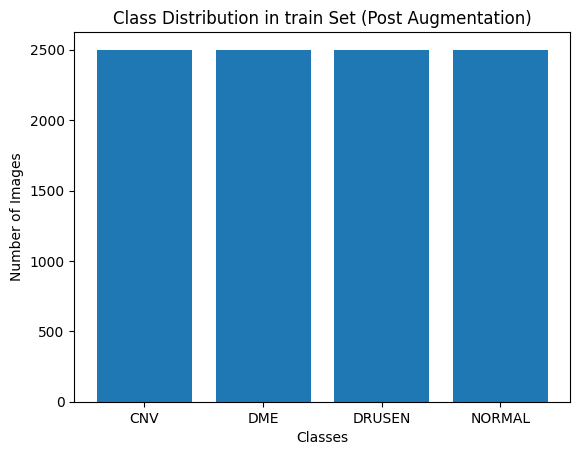

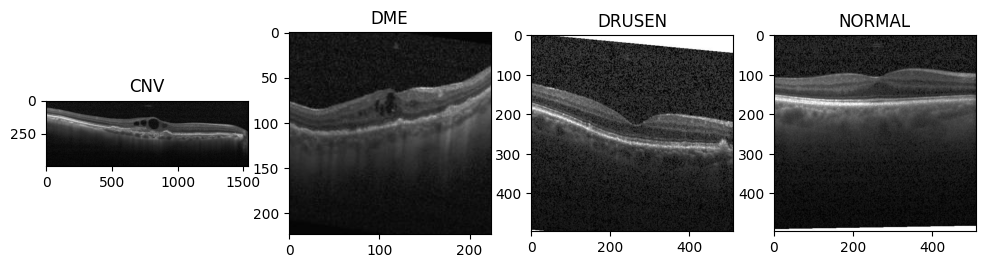

Sample training data tensor
(Image([[[ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        ...,
        [-1.6384, -1.6555, -1.6384,  ..., -1.6042, -1.6898, -0.2856],
        [-1.6384, -1.5185, -1.5870,  ..., -1.7754, -1.8097, -0.3198],
        [-1.6384, -1.5870, -1.5870,  ..., -1.8097, -1.6898, -0.3198]],

       [[ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        ...,
        [-1.5455, -1.5630, -1.5455,  ..., -1.5105, -1.5980, -0.1625],
        [-1.5455, -1.4230, -1.4930,  ..., -1.6856, -1.7206, -0.1975],
        [-1.5455, -1.4930, -1.4930,  ..., -1.7206, -1.5980, -0.1975]],

       [[ 2.6400,  2.6400,  2.6400,  ...,  2.6400,  2.6400,  2.6400],
        [ 2.6400,  2.6400,  2.6

In [5]:
# ---------------------- Training Dataset Initialization ----------------------

# Pre Augmentation Visualization
print(f"Visualizing dataset statistics for train set (Pre Augmentation):")
for category, image_count in zip (categories, image_counts):
    print(f"{category}: {image_count} images")

# Plot class distribution
plt.bar(categories, image_counts)
plt.title(f'Class Distribution in train Set (Pre Augmentation)')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()

# Post Augmentation Visualization and loading
training_data = OCTImageDataset(data_dir=train_data_dir, type='train')

training_data.visualize()
print(f'Sample training data tensor\n{training_data[0]}')

# Training Data Loader
training_data_loader = DataLoader(dataset=training_data, batch_size=batch_size, shuffle=shuffle_data)
print(training_data.counts)

Loaded 968 images for test set.
Visualizing dataset statistics for test set:
CNV: 242 images
DME: 242 images
DRUSEN: 242 images
NORMAL: 242 images


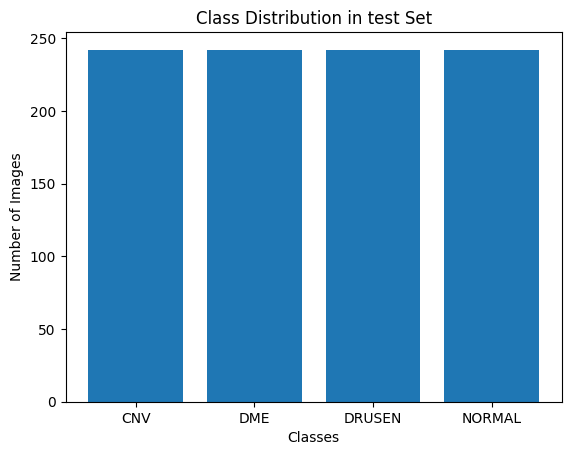

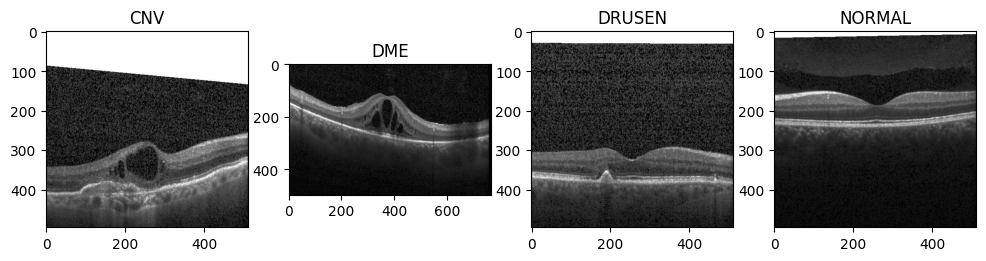

Sample testing data tensor
(Image([[[-1.8610, -1.5528, -1.7754,  ...,  2.1975,  2.2147,  2.2147],
        [-1.7069, -1.7754, -1.9467,  ...,  2.1975,  2.1975,  2.1804],
        [-1.6727, -1.7069, -1.8268,  ..., -0.5596, -0.5082, -0.8335],
        ...,
        [ 2.2489,  2.2489,  2.2489,  ..., -1.9980, -2.0837, -2.0837],
        [ 2.2489,  2.2489,  2.2489,  ..., -2.0323, -2.0837, -2.0665],
        [ 2.2489,  2.2489,  2.2489,  ..., -2.0494, -2.1008, -2.1179]],

       [[-1.7731, -1.4580, -1.6856,  ...,  2.3761,  2.3936,  2.3936],
        [-1.6155, -1.6856, -1.8606,  ...,  2.3761,  2.3761,  2.3585],
        [-1.5805, -1.6155, -1.7381,  ..., -0.4426, -0.3901, -0.7227],
        ...,
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9132, -2.0007, -2.0007],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9482, -2.0007, -1.9832],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9657, -2.0182, -2.0357]],

       [[-1.5430, -1.2293, -1.4559,  ...,  2.5877,  2.6051,  2.6051],
        [-1.3861, -1.4559, -1.63

In [6]:
# ---------------------- Testing Dataset Initialization ----------------------

testing_data = OCTImageDataset(data_dir=test_data_dir, type='test')
testing_data.visualize()
print(f'Sample testing data tensor\n{testing_data[0]}')

# Testing Data Loader
testing_data_loader = DataLoader(dataset=testing_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 32 images for val set.
Visualizing dataset statistics for val set:
CNV: 8 images
DME: 8 images
DRUSEN: 8 images
NORMAL: 8 images


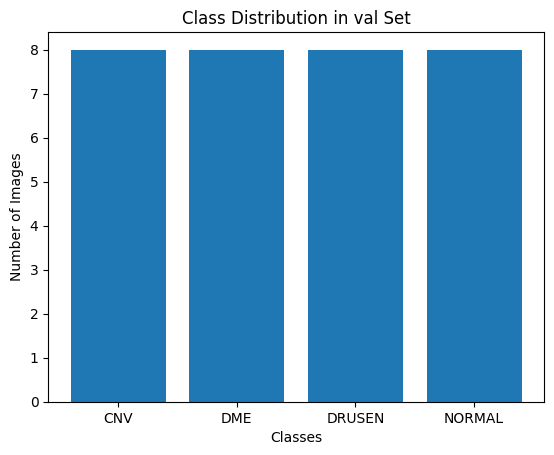

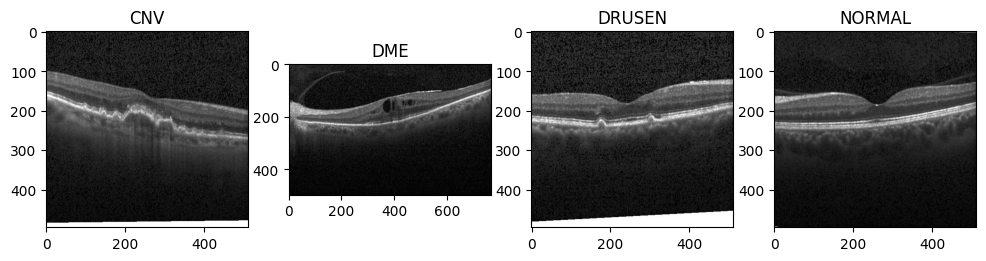

Sample validation data tensor
(Image([[[ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        ...,
        [-1.8097, -1.8610, -1.8268,  ..., -2.0494, -1.9467, -1.9809],
        [-1.7583, -1.8268, -1.7925,  ..., -1.9980, -1.9467, -1.9638],
        [-1.8268, -1.8953, -1.8439,  ..., -1.8782, -1.9980, -2.0494]],

       [[ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        ...,
        [-1.7206, -1.7731, -1.7381,  ..., -1.9657, -1.8606, -1.8957],
        [-1.6681, -1.7381, -1.7031,  ..., -1.9132, -1.8606, -1.8782],
        [-1.7381, -1.8081, -1.7556,  ..., -1.7906, -1.9132, -1.9657]],

       [[ 2.6400,  2.6400,  2.6400,  ...,  2.6400,  2.6400,  2.6400],
        [ 2.6400,  2.6400,  2

In [7]:
# ---------------------- Validation Dataset Initialization ----------------------

val_data = OCTImageDataset(data_dir=val_data_dir, type='val')
val_data.visualize()
print(f'Sample validation data tensor\n{val_data[0]}')

# Validation Data Loader
val_data_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=shuffle_data)

## Machine Learning Model: ResNet-50 Transfer Learning

### Resources Used

- https://www.geeksforgeeks.org/deep-learning/how-to-implement-transfer-learning-in-pytorch/
- Code from previous assignments, Assignment 2 and Assignment 3
- GitHub Copilot Autocomplete was used to help construct some sections of the code, in addition to helping autocomplete some redundent code elements that were already present in the code and just needed to be written again and writing the comments seen throughout the code. Since data is not available regarding the carbon emissions of GitHub Copilot autocomplete, I will be treating each autocomplete as a ChatGPT querry as GitHub Copilot is powered by ChatGPT. Therefore, using the provided metric of 4.32g of carbon emissions for a ChatGPT querry, we will be estimating my total carbon emission for using GitHub Copilot autocomplete for comments and writing redudent code at 4.32g x 30 = 129.6g.

**Total Carbon Emission Emerging from GitHub Copilot Autcomplete:** 216g

In [9]:
# ---------------------- ResNet-50 Model Definition ----------------------

class CustomResNet(nn.Module):
    def __init__(self,):
        super(CustomResNet, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(self.resnet.children())[:-1]) 
        self.classifier = nn.Linear(self.resnet.fc.in_features, 4)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [10]:
# ------------------------ Training and Validation Phase ----------------------

filename = 'Trained_Model/trained_resnet50_10000_images.pth'

def train_validate_model(model, training_data_loader, val_data_loader, device, optimizer, criterion, warmup_scheduler, patience, threshold, num_epochs):
        # Training and validation loss/accuracy counters
        train_losses = []
        train_accuracies = []
        val_losses = []
        val_accuracies = []

        # Epoch numbers for plotting
        epochs_list = []

        # Early stopping variables
        patience_counter = 0
        best_val_loss = float('inf')
        best_model_state = None
        
        # Going through each epoch
        for epoch in range(num_epochs):

            epochs_list.append(epoch + 1)

            # ---------------------- Training Phase ----------------------
            # Set model to training mode
            model.train()

            # Reset running loss, correct training amount, and total train amount for each epoch
            running_loss = 0.0
            train_correct = 0
            train_total = 0

            # Iterate over training data
            for images, labels in training_data_loader:
                # Move data to the appropriate device
                images, labels = images.to(device), labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Running forward pass
                outputs = model(images)

                # Compute loss and backpropagate
                loss = criterion(outputs, labels)
                loss.backward()

                # Update model parameters
                optimizer.step()

                # Step the scheduler
                # It will say 'epoch' is deprecated but it's needed for the warmup scheduler to work properly
                warmup_scheduler.step(epoch)

                # Update running loss and accuracy
                running_loss += loss.item()

                # Extracts predicted class index for each sample in the batch
                _, predicted = torch.max(outputs.data, 1)

                # Adds batch size to the running total number of samples processed
                train_total += labels.size(0)

                # Adds number of correct predictions to running total
                train_correct += (predicted == labels).sum().item()

            # Compute average loss and accuracy for the epoch
            avg_train_loss = running_loss / len(training_data_loader)
            train_losses.append(avg_train_loss)
            train_accuracy = train_correct / train_total
            train_accuracies.append(train_accuracy)

            # ---------------------- Validation Phase ----------------------
            # Initialize validation loss and accuracy counters
            val_running_loss = 0.0
            val_correct = 0
            val_total = 0
            
            # Set model to evaluation mode (Validation)
            model.eval()

            # Iterate over validation data while stopping gradient computation
            # This is important to prevent updating model parameters during validation
            # It also reduces memory consumption
            with torch.no_grad():
                for images, labels in val_data_loader:
                    # Move data to the appropriate device
                    images, labels = images.to(device), labels.to(device)

                    # Running forward pass
                    outputs = model(images)

                    # Compute loss
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item()

                    # Extracts predicted class index for each sample in the batch
                    _, predicted = torch.max(outputs.data, 1)

                    # Adding batch size to the running total number of samples processed
                    val_total += labels.size(0)

                    # Compares predicted labels to true labels and sums correct predictions
                    val_correct += (predicted == labels).sum().item()
            
            # Compute average loss and accuracy for validation
            val_loss = val_running_loss / len(val_data_loader)
            val_accuracy = val_correct / val_total
            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)
            
            # Printing epoch-wise performance
            print(f'Epoch [{epoch+1}/{num_epochs}]:')
            print(f'Training - Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
            print(f'Validation - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

            # Early Stopping Check
            if best_val_loss - val_loss <= threshold:
                patience_counter += 1
                if patience_counter >= patience:
                    print('\n############################ ALERT ############################')
                    print(f'Early stopping triggered after {epoch+1} epochs.')
                    print('###############################################################')
                    best_model_state = copy.deepcopy(model.state_dict())
                    # Load the best model state before stopping
                    break
            else:
                patience_counter = 0
                best_val_loss = val_loss
        
        # Plot the training and validation loss over epochs
        plt.figure(figsize=(12, 5))
        plt.plot(epochs_list, train_losses, label='Training Loss', marker='o')
        plt.plot(epochs_list, val_losses, label='Validation Loss', marker='x')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Saving the best model state
        best_model_state = model.state_dict()
        
        # Saving the model
        model_save_path = filename
        torch.save(best_model_state, model_save_path)
        print(f'\nModel saved to {model_save_path}')

        return best_model_state

In [11]:
# ------------------------ Testing Phase ----------------------

def test_model(model, testing_data_loader, device):
    # Correct and total for accuracy calculation
    correct = 0
    total = 0

    # Confusion matrix counters
    test_predicted_list = []
    test_labels_list = []

    # Testing Loop
    # Set model to evaluation mode (Testing)
    model.eval()

    # Iterate over testing data while stopping gradient computation
    # This is important to prevent updating model parameters during testing
    # It also reduces memory consumption
    with torch.no_grad():
        # Evaluate on test data
        for images, labels in testing_data_loader:
            # Move data to the appropriate device
            images, labels = images.to(device), labels.to(device)

            # Get model outputs
            outputs = model(images)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1) # Get the index of the maximum value

            # Store predicted and true labels for confusion matrix
            # Moving it to the cpu in case it was on gpu memory
            test_predicted_list.extend(predicted.cpu().numpy())
            test_labels_list.extend(labels.cpu().numpy())

            # Update correct and total counts
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Final Test Accuracy
    test_accuracy = correct / total
    print(f'Final Test Accuracy: {test_accuracy:.4f}')

    # Confusion Matrix after Testing
    print(f'\nConfusion Matrix after Testing:')
    cm = confusion_matrix(test_labels_list, test_predicted_list)
    matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
    matrix_display.plot()
    plt.title(f"Confusion Matrix for Testing Data")
    plt.show()

Using device: cuda

-----------------------------------------------------------------------------
------------------------ Training and Validation Phase ----------------------
-----------------------------------------------------------------------------


c:\Users\ishpr\Documents\GitHub\RetinalDiseasesOCTClassifier\al3pvenv\lib\site-packages\torch\optim\lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch [1/100]:
Training - Train Loss: 1.4055, Train Accuracy: 0.2310
Validation - Val Loss: 1.4124, Val Accuracy: 0.1250
Epoch [2/100]:
Training - Train Loss: 0.6634, Train Accuracy: 0.8431
Validation - Val Loss: 0.4599, Val Accuracy: 0.9375
Epoch [3/100]:
Training - Train Loss: 0.4894, Train Accuracy: 0.9371
Validation - Val Loss: 0.4119, Val Accuracy: 0.9688
Epoch [4/100]:
Training - Train Loss: 0.4460, Train Accuracy: 0.9609
Validation - Val Loss: 0.4447, Val Accuracy: 0.9688
Epoch [5/100]:
Training - Train Loss: 0.4316, Train Accuracy: 0.9671
Validation - Val Loss: 0.4215, Val Accuracy: 0.9688
Epoch [6/100]:
Training - Train Loss: 0.4228, Train Accuracy: 0.9718
Validation - Val Loss: 0.3737, Val Accuracy: 1.0000
Epoch [7/100]:
Training - Train Loss: 0.4022, Train Accuracy: 0.9805
Validation - Val Loss: 0.5519, Val Accuracy: 0.9375
Epoch [8/100]:
Training - Train Loss: 0.3873, Train Accuracy: 0.9883
Validation - Val Loss: 0.3963, Val Accuracy: 0.9688
Epoch [9/100]:
Training - Train 

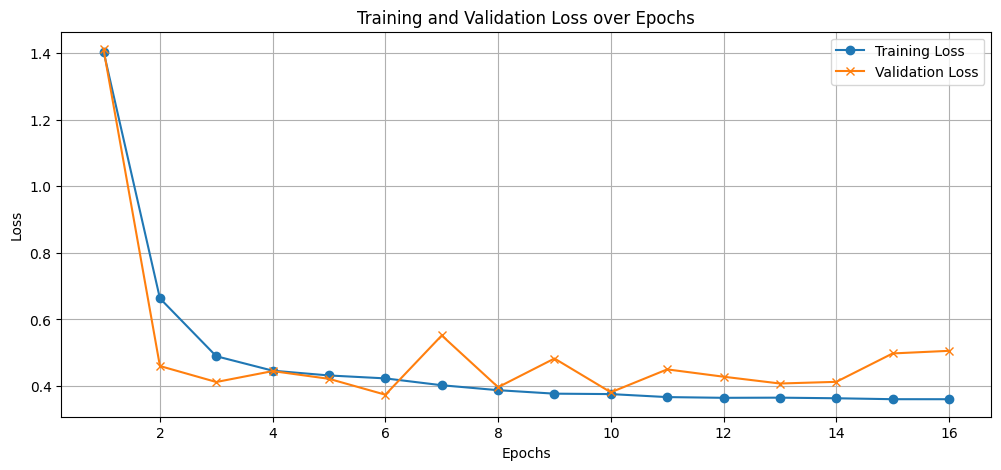


Model saved to Trained_Model/trained_resnet50_10000_images.pth

-------------------------------------------------------------------------------
------------------------------- Testing Phase ---------------------------------
-------------------------------------------------------------------------------
Final Test Accuracy: 0.9897

Confusion Matrix after Testing:


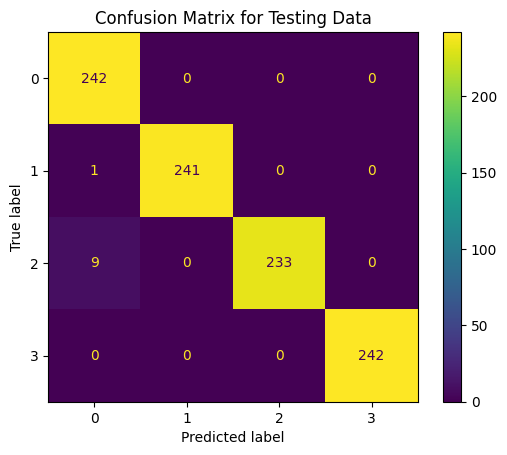

In [12]:
# ------------------------ Main Execution ----------------------

if __name__ == '__main__':

    # Selecting the graphics card if available
    # defaulting to cpu if not available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    # Instantiate the CustomResNet model, passing the pretrained model
    model = CustomResNet().to(device)

    # Freeze all layers except the last three in ResNet and classifer layer we added
    for layer in list(model.features.children())[:-3]:
        for param in layer.parameters():
            param.requires_grad = False

    # Setting model hyperparameters (short training for testing purposes)
    EPOCHS = 100
    WARMUP_EPOCHS = 5
    LEARNING_RATE = 0.01
    WEIGHT_DECAY = 0.0001
    PATIENCE = 10
    THRESHOLD = 0.0001

    # Define loss function (criterion)
    # Used: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Used: https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html
    # Nesterov gives the optimizer a lookahead capability, potentially improving convergence
    optimize_layers = filter(lambda p: p.requires_grad, model.parameters()) # GitHub Copilot suggestion
    optimizer = torch.optim.SGD(optimize_layers, lr=LEARNING_RATE, momentum=0.9, weight_decay=WEIGHT_DECAY, nesterov=True)

    # Learning rate scheduler
    # Used: https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)

    # Warm-up scheduler
    # Used: https://www.kaggle.com/datasets/aryankhatana/pytorch-warmup-scheduler
    # This sets the learning rate to gradually increase over the first WARMUP_EPOCHS number of epochs to help stabilize training (warm up)
    # Then after, hands it off to the cosine annealing scheduler defined above as the scheduler for the rest of training
    warmup_scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=WARMUP_EPOCHS, after_scheduler=scheduler)

    # Train the model
    print(f"\n-----------------------------------------------------------------------------")
    print(f"------------------------ Training and Validation Phase ----------------------")
    print(f"-----------------------------------------------------------------------------")

    # Check if trained model already exists
    if os.path.exists(filename):
        print("Trained model already exists. Skipping training.")
        best_model_state = torch.load(filename, map_location=device)
    else:
        # Train and validate the model
        best_model_state = train_validate_model(model, training_data_loader, val_data_loader, device, optimizer, criterion, warmup_scheduler, PATIENCE, THRESHOLD, EPOCHS)

    model = CustomResNet().to(device)
    model.load_state_dict(best_model_state)

    print(f"\n-------------------------------------------------------------------------------")
    print(f"------------------------------- Testing Phase ---------------------------------")
    print(f"-------------------------------------------------------------------------------")
    # Test the model
    test_model(model, testing_data_loader, device)